# 3. Context evaluation

This notebook loads the association model and compares identical noisy inputs
under inactive and active context. It reports reconstruction error and the
average change in the latent representation.

Run notebook 2 first. Both notebooks must use the same `QUICK_RUN` setting.

In [1]:
import os
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".jupyter_runtime" / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

In [2]:
import torch

from src.config import ExperimentConfig
from src.data import create_mnist_loaders
from src.evaluation import reconstruction_mse
from src.models import Autoencoder
from src.utils import add_noise, generate_context, seed_everything
from src.visualization import save_context_comparison

QUICK_RUN = True
output_dir = ROOT / "outputs" / ("notebook_quick" if QUICK_RUN else "portfolio")
required = [output_dir / "config.json", output_dir / "association.pt"]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(f"Run notebook 02 first. Missing: {missing}")

config = ExperimentConfig.load(output_dir / "config.json")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed_everything(config.seed)
_, test_loader = create_mnist_loaders(ROOT / "data", config.batch_size)
model = Autoencoder(config.capacity, config.latent_dims, config.context_dim).to(device)
model.load_state_dict(torch.load(
    output_dir / "association.pt", map_location=device, weights_only=True
))
model.eval()
print(f"Loaded: {output_dir.relative_to(ROOT) / 'association.pt'}")
print(f"Device: {device}")

Loaded: outputs\notebook_quick\association.pt
Device: cpu


## Quantitative reconstruction comparison

In [3]:
max_batches = 20 if QUICK_RUN else None
mse_without = reconstruction_mse(
    model, test_loader, config, device, use_context=False, max_batches=max_batches
)
seed_everything(config.seed)
mse_with = reconstruction_mse(
    model, test_loader, config, device, use_context=True, max_batches=max_batches
)
print(f"MSE without context: {mse_without:.6f}")
print(f"MSE with context:    {mse_with:.6f}")
print(f"Context delta:       {mse_with - mse_without:+.6f}")

MSE without context: 0.295317
MSE with context:    0.295625
Context delta:       +0.000309


## Visual and latent comparison

Mean latent L2 shift: 1.049936
Mean absolute pixel shift: 0.006857


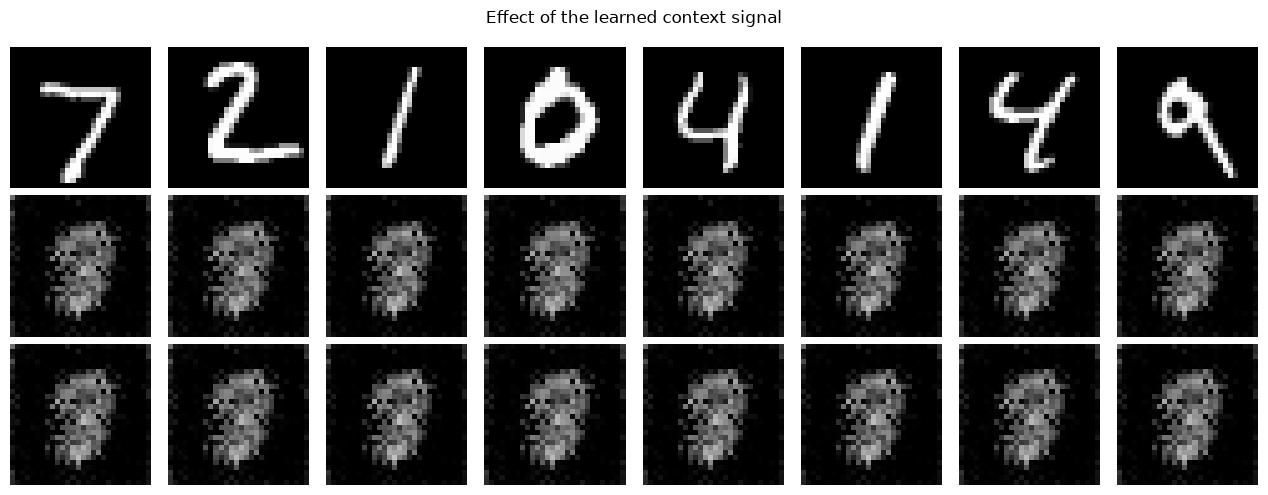

In [4]:
images, labels = next(iter(test_loader))
images = images.to(device)
noisy = add_noise(images, config.image_noise)
inactive = generate_context(
    len(images), noise_level=config.context_noise,
    category_id=config.context_channel, context_dim=config.context_dim, device=device
)
active = inactive.clone()
active[:, config.context_channel] = config.context_signal

with torch.inference_mode():
    latent_inactive = model.encoder(noisy, inactive)
    latent_active = model.encoder(noisy, active)
    reconstruction_inactive = model.decoder(latent_inactive)
    reconstruction_active = model.decoder(latent_active)

latent_shift = (latent_active - latent_inactive).norm(dim=1).mean().item()
output_shift = (reconstruction_active - reconstruction_inactive).abs().mean().item()
print(f"Mean latent L2 shift: {latent_shift:.6f}")
print(f"Mean absolute pixel shift: {output_shift:.6f}")
save_context_comparison(
    images, reconstruction_inactive, reconstruction_active,
    ROOT / "assets" / "context_effect.png"
)

**Interpretation.** The latent and pixel shifts confirm that the context channel
affects model behavior. The sign and magnitude of the MSE delta must be judged
after full training and alongside target-specific behavioral analysis; a lower
global MSE alone does not demonstrate a perceptual bias toward digit `3`.